### Perspective Transformation using OpenCV

Perspective transformation allows you to change the perspective of an image by mapping a quadrilateral region from the source image to a quadrilateral region in the destination image. This is useful for correcting perspective distortions or for creating special effects.

Here are the steps involved:

1.  **Load the image**: Load the image you want to transform.
2.  **Define Source Points (src_pts)**: Select four points in the original image that form a quadrilateral. These points define the region you want to transform.
3.  **Define Destination Points (dst_pts)**: Select four corresponding points in the output image where the `src_pts` will be mapped. These points define the shape and perspective of the transformed region.
4.  **Get Perspective Transformation Matrix (M)**: Use `cv2.getPerspectiveTransform(src_pts, dst_pts)` to compute the 3x3 transformation matrix.
5.  **Apply Perspective Transformation**: Use `cv2.warpPerspective(image, M, (width, height))` to apply the transformation using the calculated matrix and specify the output image size.
6.  **Display Results**: Show the original and transformed images.

Image loaded successfully. Dimensions: 750x864
Original Image:


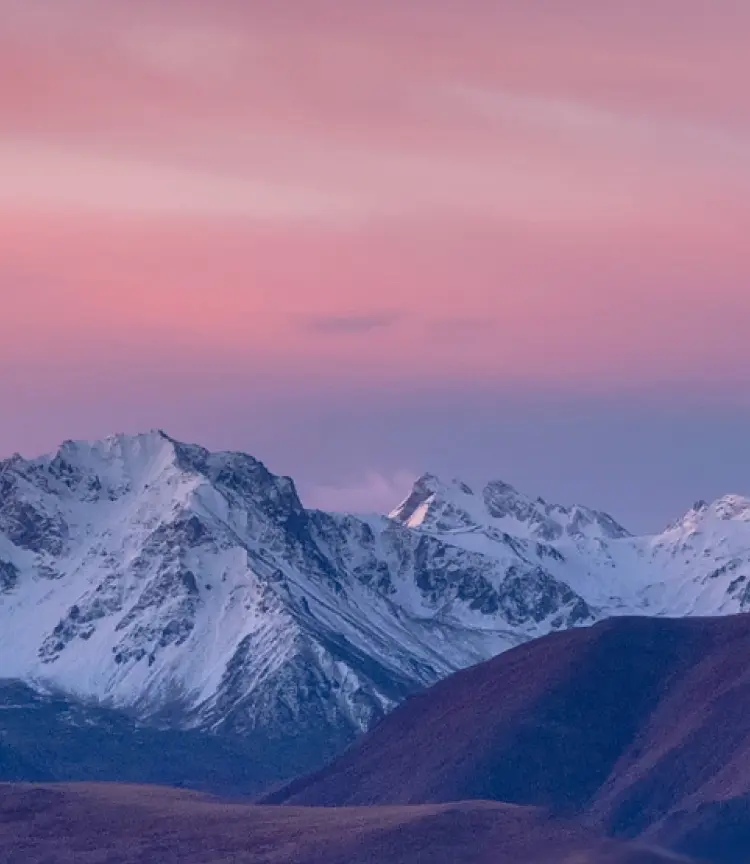

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

# --- Step 1: Load an image ---
# You can upload an image or provide a path to an existing image.
# For demonstration, let's create a dummy blank image or use a sample if available.
# Replace 'your_image.jpg' with the actual path to your image.
# If you don't have an image, you can create a dummy one for testing:
# image = np.zeros((400, 600, 3), dtype=np.uint8)
# cv2.putText(image, 'Sample Image', (100, 200), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

# Example: Load 'image 1.webp'
image = cv2.imread('/content/image 1.webp')

if image is None:
    print("Error: Could not load image. Please check the path.")
else:
    height, width = image.shape[:2]
    print(f"Image loaded successfully. Dimensions: {width}x{height}")

    # Draw a rectangle on the image (commented out as we are loading an existing image)
    # rect_color = (0, 0, 255) # Blue
    # rect_thickness = -1 # Filled
    # cv2.rectangle(image, (100, 50), (400, 350), rect_color, rect_thickness)
    # cv2.putText(image, 'Original Object', (150, 200), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    print("Original Image:")
    cv2_imshow(image)


In [2]:
# --- Step 2 & 3: Define Source and Destination Points ---
# These points define a quadrilateral in the original image (src_pts)
# and where they will be mapped in the new image (dst_pts).
# You will need to adjust these points based on your specific image and desired transformation.

# Example for the rectangle drawn above:
# The corners of the filled rectangle (approximate):
src_pts = np.float32([
    [100, 50],  # Top-left of the rectangle
    [400, 50],  # Top-right
    [400, 350], # Bottom-right
    [100, 350]  # Bottom-left
])

# Define the destination points for a new perspective.
# Let's make it look like it's viewed from an angle.
# You can change these to achieve different perspective effects.
# The order of points should correspond to src_pts (e.g., top-left, top-right, bottom-right, bottom-left).
dst_pts = np.float32([
    [50, 0],    # New top-left
    [450, 0],   # New top-right
    [width - 50, height], # New bottom-right
    [0, height] # New bottom-left
])

print("Source Points:\n", src_pts)
print("Destination Points:\n", dst_pts)


Source Points:
 [[100.  50.]
 [400.  50.]
 [400. 350.]
 [100. 350.]]
Destination Points:
 [[ 50.   0.]
 [450.   0.]
 [700. 864.]
 [  0. 864.]]


In [3]:
# --- Step 4: Get Perspective Transformation Matrix ---
M = cv2.getPerspectiveTransform(src_pts, dst_pts)

print("Transformation Matrix (M):\n", M)


Transformation Matrix (M):
 [[ 1.24444444e+00 -1.55555556e-01 -7.00000000e+01]
 [ 0.00000000e+00  1.53600000e+00 -7.68000000e+01]
 [-0.00000000e+00 -1.33333333e-03  1.00000000e+00]]


Transformed Image:


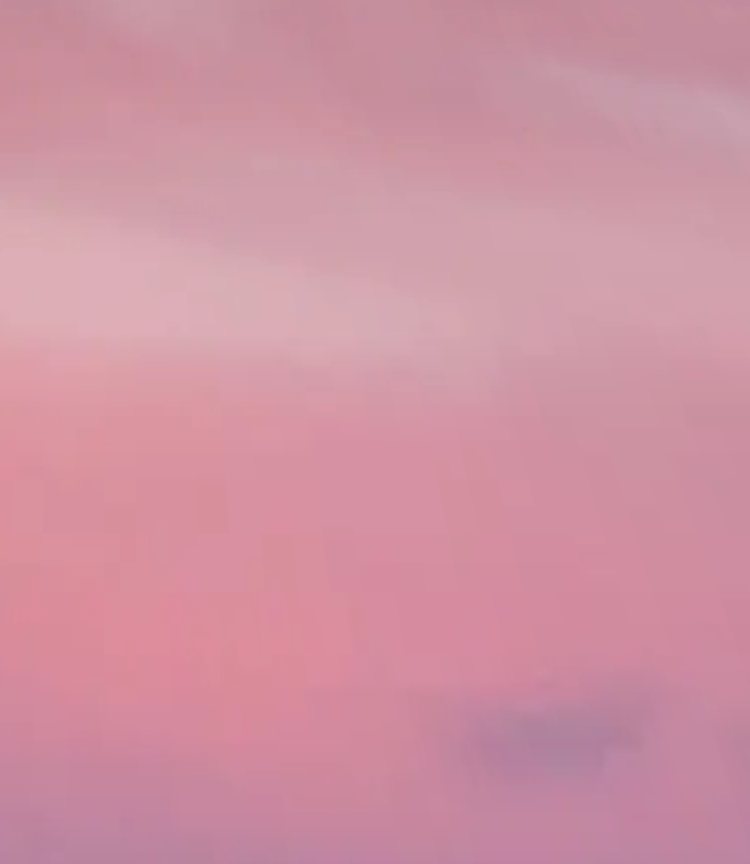

In [4]:
# --- Step 5: Apply Perspective Transformation ---
# The output size (width, height) should be appropriate for your transformation.
# Use the same width and height as the original image or adjust as needed.
transformed_image = cv2.warpPerspective(image, M, (width, height))

# --- Step 6: Display the transformed image ---
print("Transformed Image:")
cv2_imshow(transformed_image)
